In [1]:
import numpy as np

/tmp/ipykernel_1462645/2419147164.py:222: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


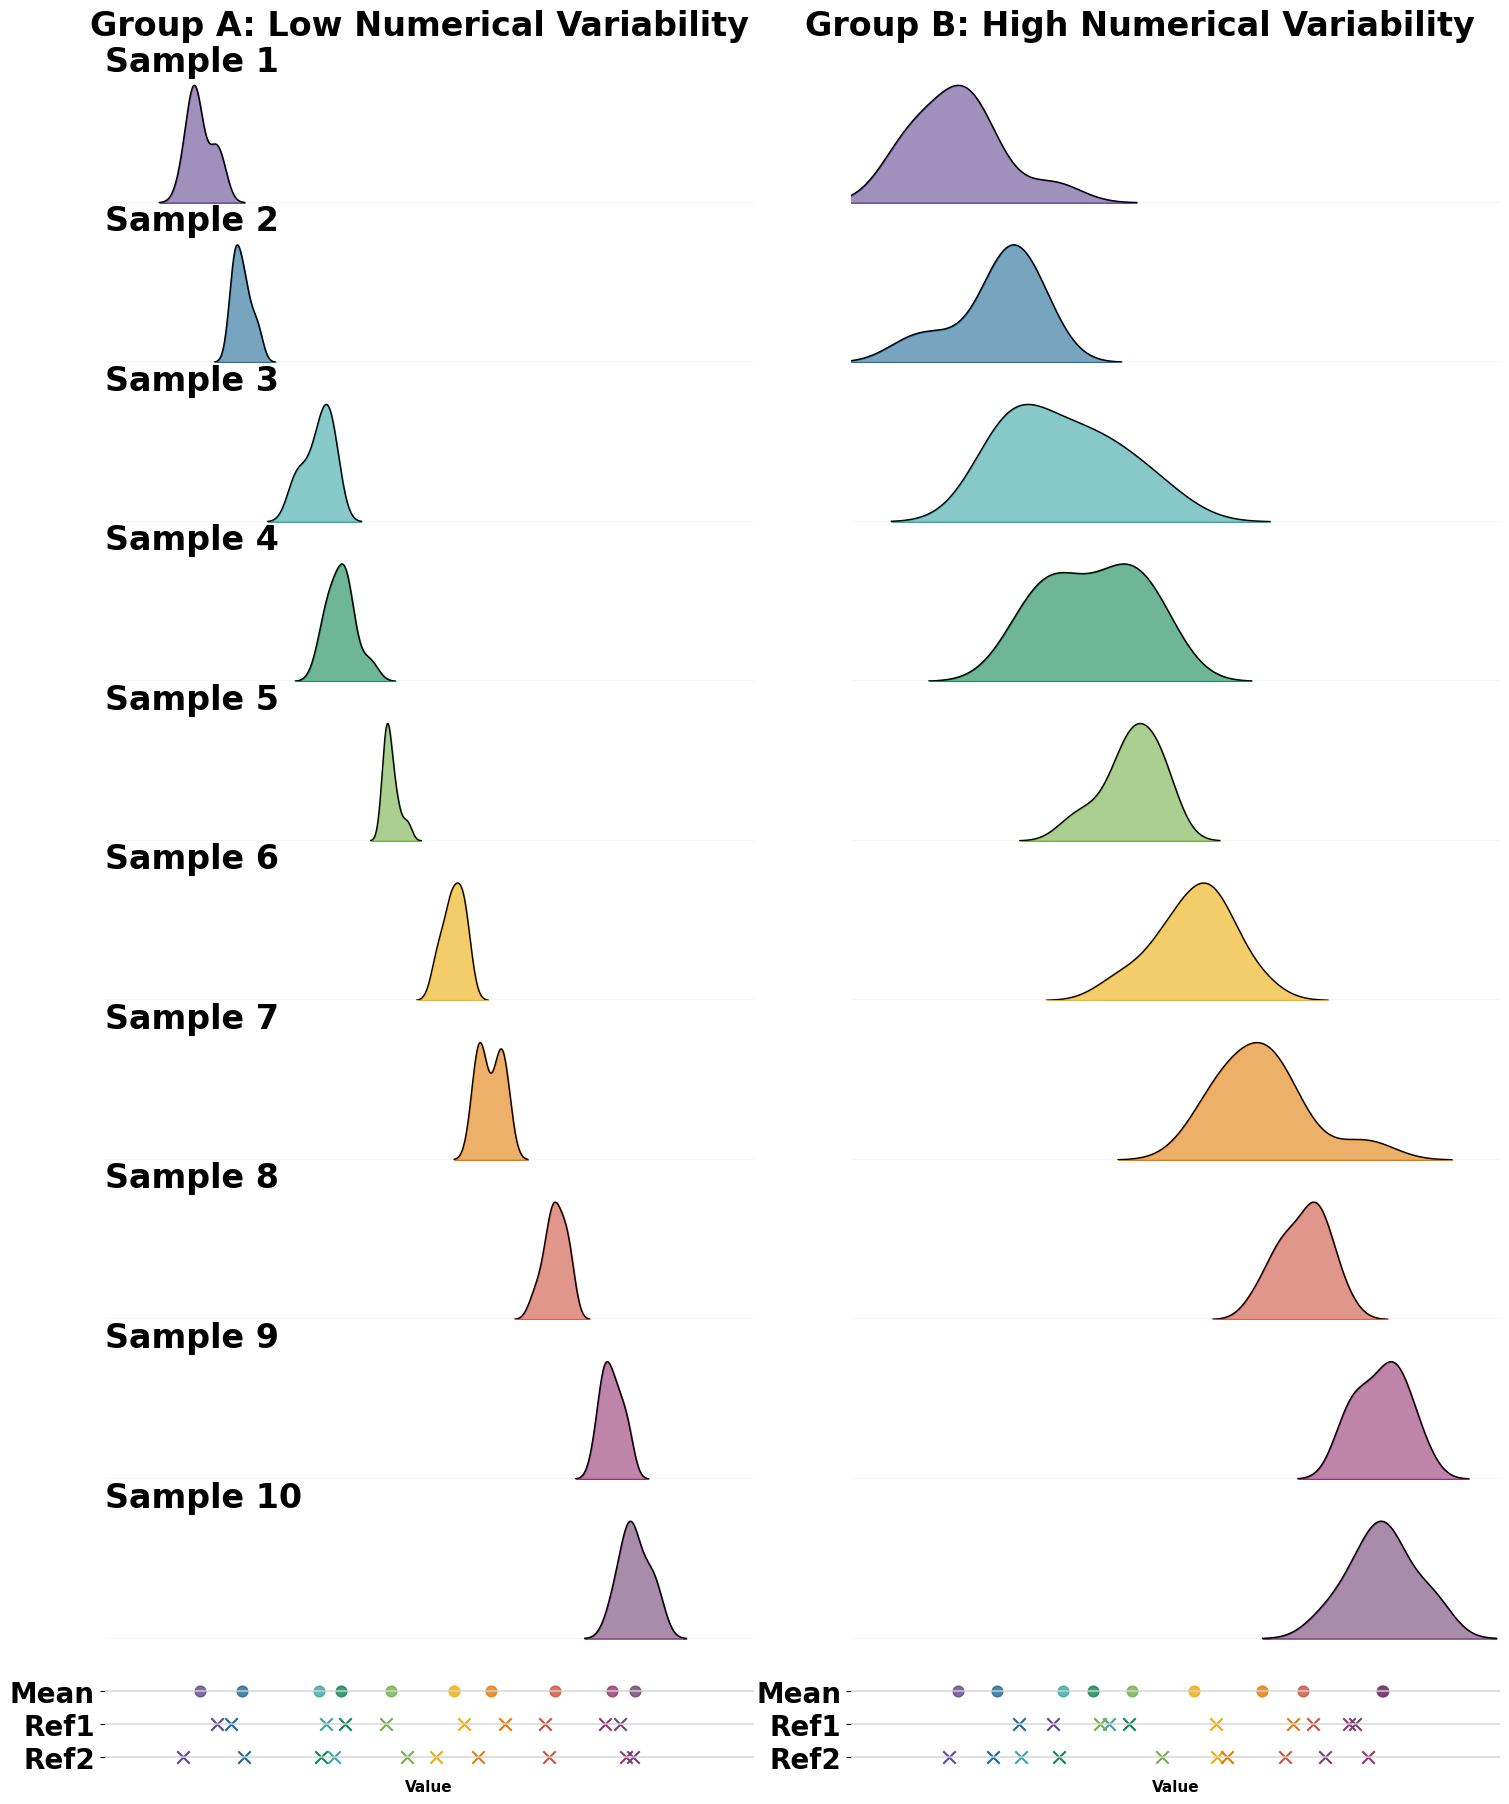

In [2]:
#two synthetic populations of ten subjects each were generated under “low” and “high” 259259 within-individual variability conditions with the same mean. 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import pandas as pd
from matplotlib import gridspec
from pathlib import Path

import matplotlib.colors as mcolors

np.random.seed(41)


def find_project_root(start: Path | None = None) -> Path:
    """Locate the numerical-variability project from any launch directory."""
    start = (start or Path.cwd()).resolve()
    nested = Path(
        "overlap/allbatches/Allpop/pickles/"
        "Numerical-Variability-of-functional-MRI-Graph-Measures"
    )
    for base in (start, *start.parents):
        for candidate in (base, base / nested):
            if (candidate / "Fig1-simulation/Fig1-simulation.ipynb").is_file():
                return candidate
    raise FileNotFoundError("Could not locate the numerical-variability project.")


PROJECT_ROOT = find_project_root()
FIGURE_DIR = PROJECT_ROOT / "Fig1-simulation"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(figure: plt.Figure, stem: str) -> None:
    """Save vector PDF and 300-dpi LZW-compressed TIFF outputs."""
    figure.savefig(FIGURE_DIR / f"{stem}.pdf", dpi=300, bbox_inches="tight")
    figure.savefig(
        FIGURE_DIR / f"{stem}.tif", format="tiff", dpi=300,
        bbox_inches="tight", pil_kwargs={"compression": "tiff_lzw"},
    )
    print(f"Saved: {FIGURE_DIR / f'{stem}.tif'}")


def plot_kde(values: np.ndarray, axis: plt.Axes, color: str) -> None:
    """Plot a filled Gaussian KDE without requiring seaborn."""
    values = np.asarray(values, dtype=float)
    spread = max(float(np.std(values)), 1e-6)
    grid = np.linspace(values.min() - 3 * spread, values.max() + 3 * spread, 256)
    density = gaussian_kde(values)(grid)
    axis.fill_between(grid, density, color=color, alpha=0.6)
    axis.plot(grid, density, color="black", linewidth=1)


# ---- Generate distributions ----
n_samples = 10
n_dists = 10

# Base X positions (means)
X = np.linspace(1, 5, n_dists)

# --- APPLY FEEDBACK ---
# Add random offsets to Population A means to increase variability
# (so they're not perfectly aligned with Population B)
X = X + np.random.uniform(-0.15, 0.15, size=n_dists)  # smaller jitter for B

# Low and high variability distributions (Population A and B)
low_var_dists = np.random.normal(loc=X, scale=0.1, size=(n_samples, n_dists))  # ↑ mean variability, slightly ↑ sigma
high_var_dists = np.random.normal(loc=X, scale=0.4, size=(n_samples, n_dists))

def convert_rgb2hex(rgbstr):
  c = rgbstr.strip('rgb(').strip(')').split(',')
  return mcolors.rgb2hex(tuple([int(c[0])/255,
                                int(c[1])/255,
                                int(c[2])/255]))

colors_low = [mcolors.to_hex(color) for color in plt.get_cmap("tab10").colors]
colors_high = colors_low


# ---- Custom gridspec: 10 rows for KDE + 1 row for projections ----
fig = plt.figure(figsize=(18,22))
gs = gridspec.GridSpec(11, 2, height_ratios=[1]*10 + [0.8], width_ratios=[1, 1],
                      hspace=0.3, wspace=0.15)

axes_left = [fig.add_subplot(gs[i, 0]) for i in range(10)]
axes_right = [fig.add_subplot(gs[i, 1]) for i in range(10)]
ax_projection_left = fig.add_subplot(gs[10, 0])
ax_projection_right = fig.add_subplot(gs[10, 1])

# ---- Set fixed x-range to zoom in/out ----
x_range_left = (0, 6)
x_range_right = (0, 6)

# Storage for projection values
left_means, left_ref1s, left_ref2s = [], [], []
right_means, right_ref1s, right_ref2s = [], [], []

# ---- Left panel: Low variability ----
for i, row in enumerate(low_var_dists.T):
    ax = axes_left[i]
    dist = row

    # Draw horizontal baseline
    ax.axhline(y=0, color='lightgray', linewidth=1, zorder=1)

    # Plot KDE
    plot_kde(dist, ax, colors_low[i])

    ax.set_title(f"Sample {i+1}",fontsize=24,fontweight='bold', loc='left')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_yticks([])
    ax.set_xticks([])  # Remove x-axis ticks
    ax.set_xlim(x_range_left)

    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # ---- Reference points ----
    mean_val = np.mean(dist)
    ref1 = dist[2]
    ref2 = dist[5]

    # ax.scatter(ref1, 0, color="red", marker="x", s=80, zorder=5)
    # ax.scatter(ref2, 0, color="blue", marker="x", s=80, zorder=5)

    # Store values for projection
    left_means.append(mean_val)
    left_ref1s.append(ref1)
    left_ref2s.append(ref2)

# ---- Right panel: High variability ----
for i, row in enumerate(high_var_dists.T):
    ax = axes_right[i]
    dist = row

    # Draw horizontal baseline
    ax.axhline(y=0, color='lightgray', linewidth=1, zorder=1)

    # Plot KDE
    plot_kde(dist, ax, colors_high[i])

    # ax.set_title(f"Sample {i}", fontsize=9)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_yticks([])
    ax.set_xticks([])  # Remove x-axis ticks
    ax.set_xlim(x_range_right)

    # Remove spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # ---- Reference points ----
    mean_val = np.mean(dist)
    ref1 = dist[2]
    ref2 = dist[5]

    # ax.scatter(ref1, 0, color="red", marker="x", s=80, zorder=5)
    # ax.scatter(ref2, 0, color="blue", marker="x", s=80, zorder=5)

    # Store values for projection
    right_means.append(mean_val)
    right_ref1s.append(ref1)
    right_ref2s.append(ref2)

# ---- Projection panel for left (Low variability) ----
y_positions = [0.7, 0.5, 0.3]

# Plot three horizontal lines
for y_pos in y_positions:
    ax_projection_left.axhline(y=y_pos, color='lightgray', linestyle='-', alpha=0.7,
                              linewidth=1.5)

# Project means (circles) - each with its distribution color
for i, mean_val in enumerate(left_means):
    ax_projection_left.scatter(mean_val, y_positions[0],
                              color=colors_low[i], marker='o', s=60, alpha=0.8)

# Project ref1 (x markers) - each with its distribution color
for i, ref1_val in enumerate(left_ref1s):
    ax_projection_left.scatter(ref1_val, y_positions[1],
                              color=colors_low[i], marker='x', s=80)

# Project ref2 (x markers) - each with its distribution color
for i, ref2_val in enumerate(left_ref2s):
    ax_projection_left.scatter(ref2_val, y_positions[2],
                              color=colors_low[i], marker='x', s=80)

ax_projection_left.set_xlim(x_range_left)
ax_projection_left.set_ylim(0.2, 0.8)
ax_projection_left.set_yticks(y_positions)
ax_projection_left.set_yticklabels(['Mean', 'Ref1', 'Ref2'],fontsize=20, fontweight='bold')
ax_projection_left.set_xlabel('Value',fontsize=11, fontweight='bold')
# ax_projection_left.set_title('Projections', fontsize=11, fontweight='bold')

# Remove spines for projection panel
ax_projection_left.spines['top'].set_visible(False)
ax_projection_left.spines['right'].set_visible(False)
ax_projection_left.spines['left'].set_visible(False)
ax_projection_left.spines['bottom'].set_visible(False)
# ax_projection_left.set_xticklabels(
#     ax_projection_left.get_xticklabels(),
#     fontsize=11,
#     fontweight='bold'
# )
ax_projection_left.set_xticks([])


# ---- Projection panel for right (High variability) ----
# Plot three horizontal lines
for y_pos in y_positions:
    ax_projection_right.axhline(y=y_pos, color='lightgray', linestyle='-', alpha=0.7,
                               linewidth=1.5)

# Project means (circles) - each with its distribution color
for i, mean_val in enumerate(right_means):
    ax_projection_right.scatter(mean_val, y_positions[0],
                               color=colors_high[i], marker='o', s=60, alpha=0.8)

# Project ref1 (x markers) - each with its distribution color
for i, ref1_val in enumerate(right_ref1s):
    ax_projection_right.scatter(ref1_val, y_positions[1],
                               color=colors_high[i], marker='x', s=80)

# Project ref2 (x markers) - each with its distribution color
for i, ref2_val in enumerate(right_ref2s):
    ax_projection_right.scatter(ref2_val, y_positions[2],
                               color=colors_high[i], marker='x', s=80)

ax_projection_right.set_xlim(x_range_right)
ax_projection_right.set_ylim(0.2, 0.8)
ax_projection_right.set_yticks(y_positions)
ax_projection_right.set_yticklabels(['Mean', 'Ref1', 'Ref2'],fontsize=20, fontweight='bold')
ax_projection_right.set_xlabel('Value',fontsize=11, fontweight='bold')
# ax_projection_right.set_title('Projections', fontsize=11, fontweight='bold')
# Set y tick labels with style

# Remove spines for projection panel
ax_projection_right.spines['top'].set_visible(False)
ax_projection_right.spines['right'].set_visible(False)
ax_projection_right.spines['left'].set_visible(False)
ax_projection_right.spines['bottom'].set_visible(False)
# ax_projection_right.set_xticklabels(
#     ax_projection_right.get_xticklabels(),
#     fontsize=11,
#     fontweight='bold'
# )
ax_projection_right.set_xticks([])

# Add panel titles
fig.text(0.3, 0.9, "Group A: Low Numerical Variability", fontsize=24, fontweight='bold', ha='center')
fig.text(0.70, 0.9, "Group B: High Numerical Variability", fontsize=24, fontweight='bold', ha='center')

plt.tight_layout()
plt.show()
save_figure(fig, "sim1")


In [3]:
# -----------------------------------------------------------
#  COMPUTE SIGMA VALUES FOR LOW AND HIGH POPULATIONS
# -----------------------------------------------------------

# ---- LOW variability population ----

# 1. Variance within each sample (10 values per sample)
low_within_var_each = np.var(low_var_dists, axis=0, ddof=1)      # → length = 10

# 2. Average across samples
low_within_var_mean = np.mean(low_within_var_each)

# 3. Square root → this is your low_sigma_num
low_sigma_num = np.sqrt(low_within_var_mean)


# 4. Variance across samples for each “dot index” (10 dots)
low_across_var_each = np.var(low_var_dists, axis=1, ddof=1)      # → length = 10

# 5. Average across dot positions
low_across_var_mean = np.mean(low_across_var_each)

# 6. Square root → sigma_anat (low)
low_sigma_anat = np.sqrt(low_across_var_mean)



# ---- HIGH variability population ----

# 1. Variance within each sample
high_within_var_each = np.var(high_var_dists, axis=0, ddof=1)

# 2. Average across samples
high_within_var_mean = np.mean(high_within_var_each)

# 3. Square root → high sigma num
high_sigma_num = np.sqrt(high_within_var_mean)


# 4. Variance across samples for each dot index
high_across_var_each = np.var(high_var_dists, axis=1, ddof=1)

# 5. Average across dot positions
high_across_var_mean = np.mean(high_across_var_each)

# 6. Square root → sigma_anat (high)
high_sigma_anat = np.sqrt(high_across_var_mean)


print("Low σ_num      =", low_sigma_num)
print("Low σ_anat     =", low_sigma_anat)
print("High σ_num     =", high_sigma_num)
print("High σ_anat    =", high_sigma_anat)


Low σ_num      = 0.10823781642636499
Low σ_anat     = 1.3980859374445824
High σ_num     = 0.36903183744723744
High σ_anat    = 1.4561994534143472


/tmp/ipykernel_1462645/2963134918.py:51: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/tmp/ipykernel_1462645/2963134918.py:58: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


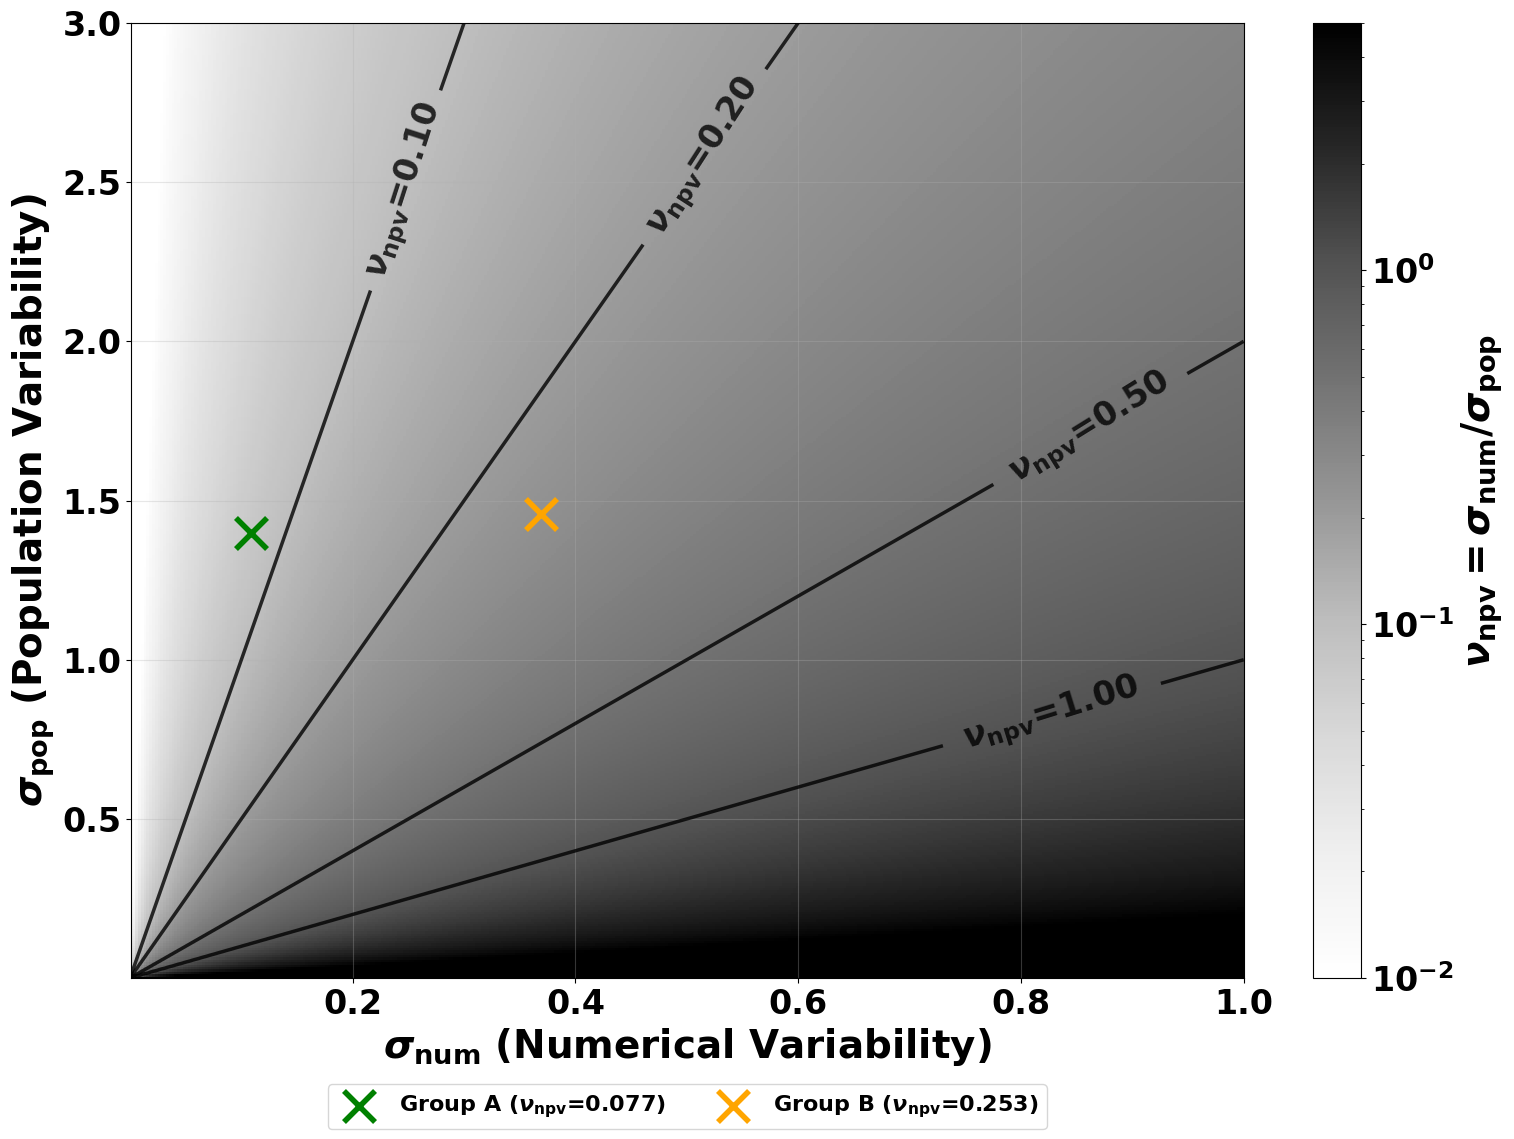

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.rcParams.update({
    'font.size': 28,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'legend.fontsize': 16,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
})

# Grid (σ_num and σ_anat both in [0.001, 1.5])
x = np.linspace(0.001, 1, 400)  # σ_num
y = np.linspace(0.001, 3, 400)  # σ_anat
X, Y = np.meshgrid(x, y)

# Variability ratio
Z = X / Y

fig, ax = plt.subplots(figsize=(16, 12))

# Log normalization for visibility
norm = LogNorm(vmin=0.01, vmax=5)
pcm = ax.pcolormesh(X, Y, Z, shading='auto', cmap='Greys', norm=norm)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r'$\nu_{\mathrm{npv}} = \sigma_{\mathrm{num}}/\sigma_{\mathrm{pop}}$')

# Contours
contour_levels = [0.1, 0.2, 0.5, 1.0]
contours = ax.contour(X, Y, Z, levels=contour_levels, colors='black',
                      linewidths=2.5, linestyles='solid', alpha=0.8)
ax.clabel(
    contours, inline=True, fontsize=24,
    fmt=lambda v: r"$\nu_{\mathrm{npv}}$=%.2f" % v,
    inline_spacing=10, colors='black'
)

# Example points - Low and High variability cases
# low_sigma_num, low_sigma_anat =0.075,  0.261
# high_sigma_num, high_sigma_anat = 0.121, 0.244

# Compute their ratios
low_ratio = low_sigma_num / low_sigma_anat
high_ratio = high_sigma_num / high_sigma_anat

# Plot dots (corrected labels)
ax.scatter(
    low_sigma_num, low_sigma_anat,
    color='green', s=500, edgecolor='k', marker='x', linewidth=4,
    label=rf'Group A ($\nu_{{\mathrm{{npv}}}}$={low_ratio:.3f})',
    zorder=10
)

ax.scatter(
    high_sigma_num, high_sigma_anat,
    color='orange', s=500, edgecolor='k', marker='x', linewidth=4,
    label=rf'Group B ($\nu_{{\mathrm{{npv}}}}$={high_ratio:.3f})',
    zorder=10
)


# # ---- ✨ Add text labels for ν_npv ----
# ax.text(low_sigma_num * 1.1, low_sigma_anat * 1.05,
#         rf"$\nu_{{\mathrm{{npv}}}}$={low_ratio:.3f}",
#         color='blue', fontsize=13, fontweight='bold')

# ax.text(high_sigma_num * 1.1, high_sigma_anat * 0.95,
#         rf"$\nu_{{\mathrm{{npv}}}}$={high_ratio:.3f}",
#         color='green', fontsize=13, fontweight='bold')

# Axes, title, legend
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_xlabel(r'$\sigma_{\mathrm{num}}$ (Numerical Variability)', fontsize=28)
ax.set_ylabel(r'$\sigma_{\mathrm{pop}}$ (Population Variability)', fontsize=28)
# ax.set_title("Variability Ratio Space", fontsize=14)
ax.grid(True, alpha=0.3)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=2
)
plt.tight_layout()
plt.show()
save_figure(fig, "sim2")


/tmp/ipykernel_1462645/1831102463.py:82: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x, high_vr, color='orange', edgecolor='black', marker='x', linewidth=3, s=500, zorder=5)


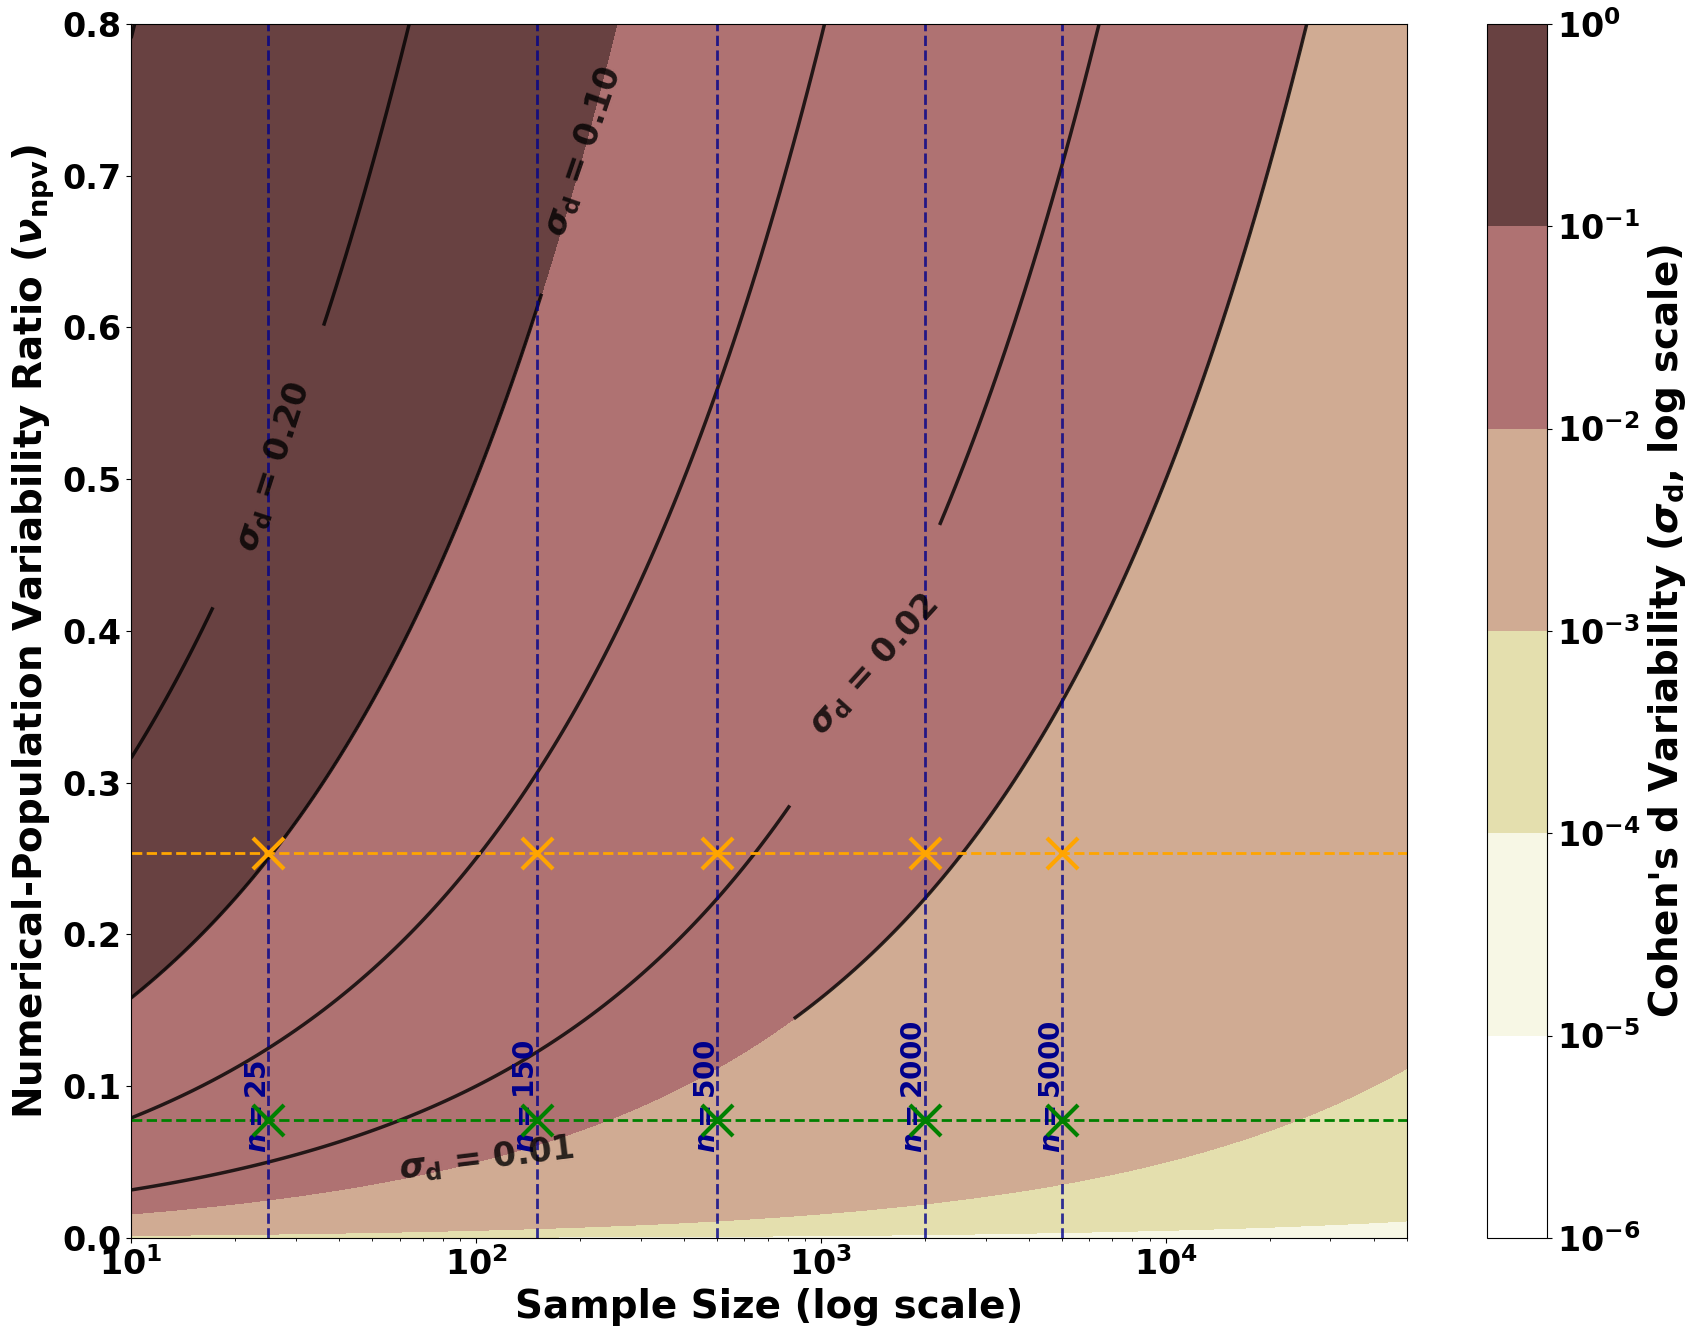

<Figure size 640x480 with 0 Axes>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.rcParams.update({
    'font.size': 28,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'legend.fontsize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
})


# Parameters
sample_sizes = np.logspace(1, 5, 300)  # 10 → 100,000
variability_ratios = np.linspace(0.0, 1.0, 300)

# Compute Cohen's d
def cohens_d(n, vr):
    return (2 / np.sqrt(n)) * vr

# Create meshgrid
N, VR = np.meshgrid(sample_sizes, variability_ratios)
D = cohens_d(N, VR)
D_safe = np.maximum(D, 1e-5)

# ---- Plot Heatmap ----
plt.figure(figsize=(18, 14))
contourf = plt.contourf(
    N, VR, D_safe, levels=50, cmap="pink_r",
    # N, VR, D_safe, levels=50, cmap="RdYlGn_r",
    norm=LogNorm(vmin=1e-5, vmax=1)
)

# ---- Add Isolines ----
contour_levels = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
contours = plt.contour(N, VR, D, levels=contour_levels, colors='black',
                      linewidths=2.5, linestyles='solid', alpha=0.8)
# plt.clabel(contours, inline=True, fontsize=18, fmt=lambda v: r"$\sigma_{\mathrm{d}}$=%.2f" % v, inline_spacing=10, colors='black' )
# plt.clabel(contours, inline=True, fontsize=18, fmt=lambda v: r"$\sigma_{\mathrm{d}}$=%.2f" % v, colors='black' )
labels = plt.clabel(
    contours,
    inline=True,
    fontsize=24,
    fmt=lambda v: r"$\sigma_{\mathrm{d}}$ = %.2f" % v,
    inline_spacing=12,
    colors='black')

angles = [7, 48, 67, 71, 72]
for a, txt in zip(angles,labels):
  txt.set_rotation(a) # force vertical
  txt.set_rotation_mode('anchor')# IMPORTANT
  txt.set_transform_rotates_text(False) #  stops contour-following
  txt.set_ha('center')
  txt.set_va('center')

# ---- Replace horizontal lines with shaded dots ----
# Variability ratios
low_vr = low_ratio
high_vr = high_ratio

# Choose 6 sample sizes spaced evenly in log scale
# dot_samples = np.logspace(np.log10(18), np.log10(10000), 6)
dot_samples = [25, 150, 500, 2000, 5000]


# Plot blue-shaded dots (low variability line)
for x in (dot_samples):
    plt.scatter(x, low_vr, color='green', s=500, marker='x', linewidth=3, zorder=5)
    plt.vlines(x, ymin=0, ymax=1, color='darkblue', linewidth=2, linestyles='dashed', alpha=0.8)
    plt.text(x*0.85, 0.06, rf"$n={{{int(x)}}}$", fontsize=20, rotation=90, color='darkblue')
    # Vertical dotted lines for fixed variability ratios
    # plt.hlines(low_vr, xmin=10, xmax=100000, colors='orange', linestyles='dotted', linewidth=1.2, alpha=0.7)
    # plt.hlines(high_vr, xmin=10, xmax=100000, colors='pink', linestyles='dotted', linewidth=1.2, alpha=0.7)
plt.hlines(y=low_vr, xmin=0, xmax=1e5, color='green', linewidth=2, linestyles='dashed')

# Plot green-shaded dots (high variability line)
for x in zip(dot_samples):
    plt.scatter(x, high_vr, color='orange', edgecolor='black', marker='x', linewidth=3, s=500, zorder=5)

plt.hlines(y=high_vr, xmin=0, xmax=1e5, color='orange', linewidth=2, linestyles='dashed')

# Legend handles (manually)
# plt.scatter([], [], color='green', edgecolor='black', marker='x', linewidth=2, s=100, label=r'Group A ($\nu_{\mathrm{npv}}$=0.287)')
# plt.scatter([], [], color='orange', edgecolor='black', marker='x', linewidth=2, s=100, label=r'Group B ($\nu_{\mathrm{npv}}$=0.496)')

# ---- Colorbar and Axis Labels ----
cbar = plt.colorbar(contourf, label=r"Cohen's d Variability ($\sigma_{\mathrm{d}}$, log scale)")

plt.xscale("log")
plt.xlabel("Sample Size (log scale)")
plt.ylabel(r"Numerical-Population Variability Ratio ($\nu_{\mathrm{npv}}$)")
# plt.title(r"Cohen's d Variability ($\sigma_{\mathrm{d}}$) Across Sample Size and Variability Ratio")

plt.ylim(0, 0.8)
plt.xlim(10, 5e4)

# plt.legend(
#     loc='upper center',
#     bbox_to_anchor=(0.5, -0.12),
#     ncol=2
# )

plt.tight_layout()
fig = plt.gcf()
plt.show()
save_figure(fig, "sim3")
